In [17]:
import os
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import json
import glob
import matplotlib.pyplot as plt

In [2]:
from Tools import load_schema
from Tools import LisParse

In [3]:
from IPython.display import JSON

In [4]:
schema = load_schema()

In [5]:
JSON(schema)

<IPython.core.display.JSON object>

In [6]:
lis_file_list = glob.glob('../data/BAM_Dataset/*.LIS')

In [7]:
lis_file = '../data/BAM_Dataset/BCR425-280-1.LIS'

In [8]:
jsoned_lis = {}

In [9]:
for lis_file in lis_file_list:
    data = LisParse.Data(lis_file)
    jsoned_lis[lis_file] = data.parse_lis()

# Define the mapping

In [10]:
import re

In [11]:
from Tools.Metainfo.metainfo import Quantity, MissingQuantity

In [12]:
from Tools.SchemaMappings.schema_mappings import map_bam_to_schema

In [13]:
schema_compliant_data = {}

In [14]:
for lis_file, jsoned_data in jsoned_lis.items():
    schema_compliant_data[lis_file] = map_bam_to_schema(schema, jsoned_data)

In [15]:
JSON(schema_compliant_data)

<IPython.core.display.JSON object>

In [16]:
for lis_file, compliant_jsoned_data in schema_compliant_data.items():
    compliant_bam_file_basename = 'compliant_'+os.path.basename(lis_file).replace('LIS','json')
    compliant_bam_file = os.path.join(os.path.dirname(lis_file), compliant_bam_file_basename)
    with open(compliant_bam_file, 'w') as f:
        json.dump(compliant_jsoned_data, f)

# Some plots 

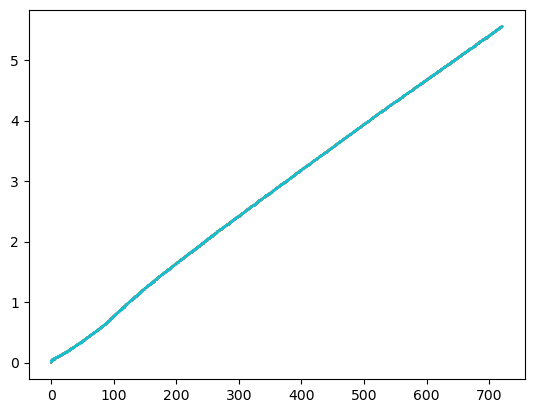

In [29]:
fig, ax = plt.subplots()
for lis_file, jsoned_data in schema_compliant_data.items():
    y = jsoned_data['Primary data']['Test results']['raw_elongations']['Value']
    x = jsoned_data['Primary data']['Test results']['raw_times']['Value']
    y_unit = jsoned_data['Primary data']['Test results']['raw_elongations']['Unit']
    x_unit = jsoned_data['Primary data']['Test results']['raw_times']['Unit']
    ax.plot(x,y)